# Czech Gas Import Capacity — Storage Sizing Analysis

**Purpose**  
This notebook estimates the level of gas imports into the Czech balancing zone
that can reliably be counted on during winter, at several risk-level scenarios.
The results are an input into a discussion about how much working gas needs to be
held in Czech underground storage (UGS) facilities so that a 1-in-20 cold-winter
demand event can be met even when imports fall short.

**Model framing**

```
Peak demand (1-in-20, exogenous)
       │
       ├─── covered by reliable imports  ←── this notebook sizes this
       │
       └─── covered by UGS withdrawal    ←── subsequent exercise
```

**Data source**  
ENTSOG Transparency Platform — Aggregated Data export for the Czech balancing
zone (operator NET4GAS), all entry directions, daily granularity.

**Key analytical decision: Physical Flows, post-March 2022 only**  
See Section 2 for the detailed rationale.  In brief:
- Physical Flows record what physically crossed the border; Allocations record
  commercial settlements.  For capacity reliability the physical record is more
  direct.
- Pre-2022 data reflects Russian transit volumes and the 2021 storage-filling
  frenzy — structurally different from today's market.  Using it would
  overstate available import capacity.

---
## 0. Setup

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import bsd.data as bdata
import bsd.capacity as bcap
import bsd.plot as bplot
from bsd.constants import FIGS_DIR

%matplotlib inline
plt.rcParams["figure.dpi"] = 130

# ── inputs ────────────────────────────────────────────────────────────────
DATA_FILE = bdata.DATA_PATH_IMPORTS
# 1-in-20 peak demand estimate provided by the demand analyst (GWh/d).
PEAK_DEMAND_GWH_D = 370.0

# Total Czech UGS working-gas capacity (TWh) — used as reference in charts.
# Source: NET4GAS system information / AGSI+ aggregate.
CZECH_UGS_CAPACITY_TWH = 45.3034 # https://agsi.gie.eu

# Analytical cutoff: exclude data before this date (Russian-transit era).
CUTOFF = bdata.DEFAULT_CUTOFF   # 2022-03-01

print(f"Peak demand assumption : {PEAK_DEMAND_GWH_D} GWh/d")
print(f"Analytical cutoff      : {CUTOFF.date()}")
print(f"Czech UGS capacity ref : {CZECH_UGS_CAPACITY_TWH} TWh")

Peak demand assumption : 370.0 GWh/d
Analytical cutoff      : 2022-03-01
Czech UGS capacity ref : 45.3034 TWh


---
## 1. Load data

We load two views of the same raw file:

1. **`daily`** — total daily imports summed across all non-storage entry points.
   This is the primary series used for percentile calculations.
2. **`daily_by_source`** — same data broken down by adjacent system (corridor).
   Used to understand which entry points drive high and low import days.
3. **`daily_full`** — same as `daily` but without the cutoff, loaded purely
   for the historical time-series chart in Section 2.

In [3]:
daily = bdata.load_daily_imports(DATA_FILE, cutoff=CUTOFF)
daily_by_source = bdata.load_daily_imports_by_source(DATA_FILE, cutoff=CUTOFF)

# Full history for the structural-break chart only.
daily_full = bdata.load_daily_imports(
    DATA_FILE,
    cutoff=pd.Timestamp("2020-01-01"),   # go back to start of dataset
)

print(f"Post-cutoff observations : {len(daily):,} days")
print(f"Date range               : {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"Winter days (Nov–Mar)    : {daily['is_winter'].sum():,}")
daily.head(3)

Post-cutoff observations : 1,550 days
Date range               : 2022-03-01 → 2026-05-28
Winter days (Nov–Mar)    : 760


,date,GWh_d,month,year,is_winter
0,2022-03-01 06:00:00,701.857089,3,2022,True
1,2022-03-02 06:00:00,758.422918,3,2022,True
2,2022-03-03 06:00:00,696.757895,3,2022,True


---
## 2. Structural break and data scope

The chart below shows the full daily import history from January 2020.  Three
features stand out:

- **2019/20 and 2020/21 winters**: consistently high flows (800–1 500 GWh/d)
  driven by Russian gas transiting through Ukraine and Slovakia into Czech
  territory and onward to Western Europe.
- **Autumn 2021 spike**: extreme values (up to 2 980 GWh/d) reflect the
  European gas storage filling race before the winter of the energy crisis.
  These are transit / storage-arbitrage flows, not Czech domestic demand.
- **Post-March 2022**: flows drop to a structurally lower plateau (~150–500
  GWh/d in winter) as Czech importers diversified away from Russian supply
  via Germany (LNG, Norwegian gas, storage releases).

Using pre-2022 data for scenario calibration would produce import-capacity
estimates that are unattainable under current market structure and would
lead to under-sizing storage requirements.

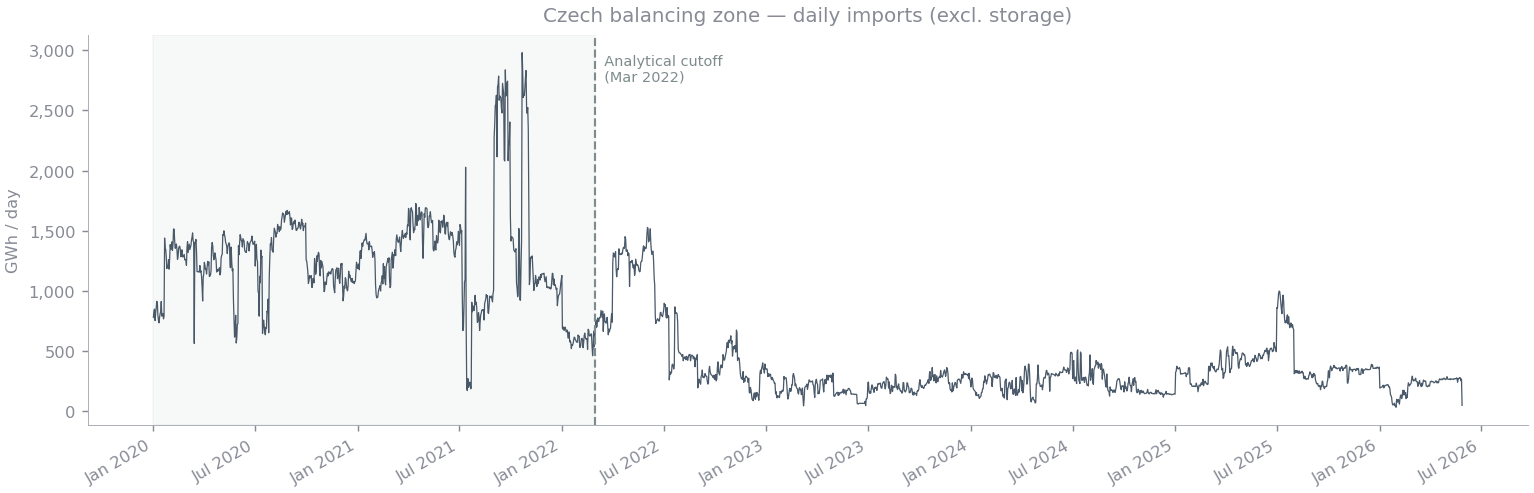

In [4]:
fig = bplot.daily_imports_timeseries(daily_full, cutoff=CUTOFF)
fig.savefig(FIGS_DIR / "daily_imports_history.png", bbox_inches="tight")
fig;

---
## 3. Corridor concentration

Before computing percentiles it is important to understand *which* corridors
drive Czech imports.  If one corridor dominates, the reliability of the total
import figure is essentially the reliability of that single connection.

The stacked area chart and the summary table below confirm that post-2022
Czech imports are almost entirely sourced through **DE THE BZ (Germany)**,
with Slovakia providing an intermittent secondary flow.  This is a strong
single-corridor concentration and an important qualitative input to the
risk discussion: a disruption on the CZ–DE interconnection would directly
map to the stressed import scenarios.

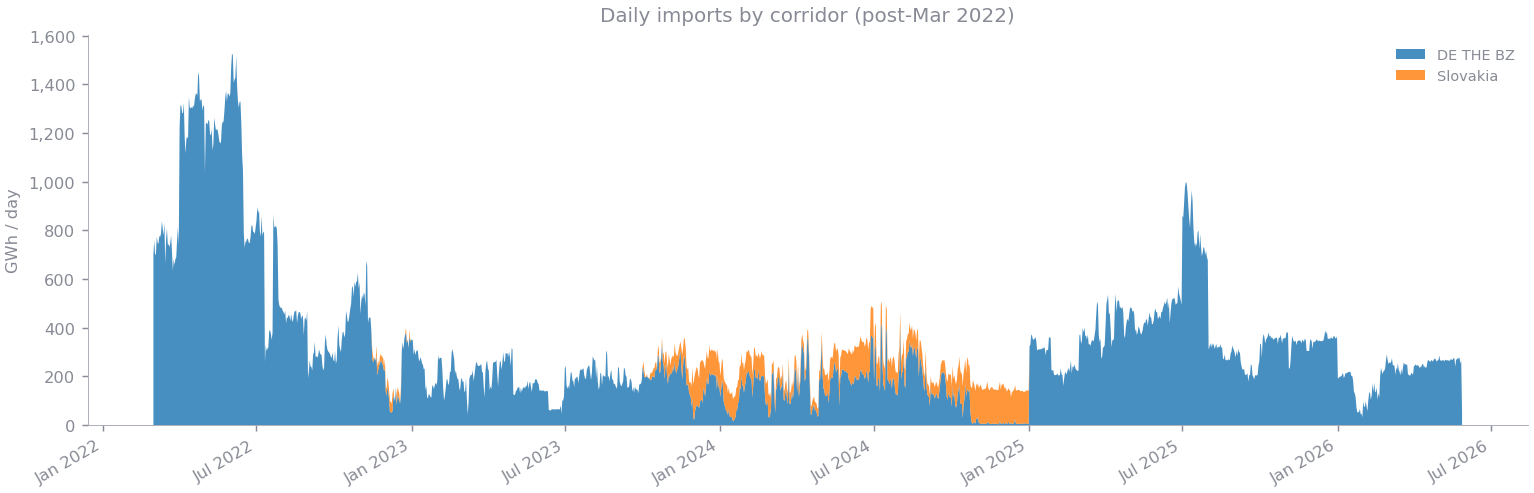

In [5]:
fig = bplot.source_stacked_area(daily_by_source)
fig.savefig(FIGS_DIR / "imports_by_corridor.png", bbox_inches="tight")
fig;

In [6]:
# Median and max contribution per corridor during winter days.
winter_src = daily_by_source[daily_by_source["is_winter"]]
(
    winter_src
    .groupby("adjacentSystemsLabel")["GWh_d"]
    .agg(median="median", mean="mean", max="max", n_nonzero=lambda x: (x > 0.1).sum())
    .round(1)
    .sort_values("median", ascending=False)
)

,median,mean,max,n_nonzero
adjacentSystemsLabel,,,,
DE THE BZ,216.5,237.8,837.2,760
"DE THE BZ,Transmission",0.0,0.0,0.0,0
Poland H-gas,0.0,0.0,0.1,0
Slovakia,0.0,35.4,176.4,306


---
## 4. Seasonal context — has post-2022 import behaviour been stable?

A natural concern is whether the four post-2022 winters (2022/23 through
2025/26) show any trend — for example, recovery of import volumes as European
gas demand partially rebounds.  The table below summarises each season.

If peak or median volumes are rising season-on-season, the percentile
estimates from the pooled 2022–2026 sample will understate what could
realistically be imported in future winters, which would in turn *overstate*
the storage requirement — a conservative bias, but worth flagging.

In [7]:
bcap.seasonal_peaks(daily)

,peak_GWh_d,p90_GWh_d,median_GWh_d,mean_GWh_d,n_days
gas_winter,,,,,
2021/22,837.2,809.3,749.5,744.0,31
2022/23,673.3,384.2,232.2,244.4,151
2023/24,361.4,306.9,250.9,234.7,152
2024/25,507.7,366.2,215.0,238.8,151
2025/26,388.6,355.2,243.9,247.1,151


---
## 5. Import capacity distribution

We now look at the empirical distribution of daily imports during winter
months (October through March), and separately at the distribution of
30-day rolling averages.  The rolling average is the operationally relevant
metric for storage sizing: storage must sustain a withdrawal *rate* over
weeks, not just cover a single peak day.

The full percentile table is printed below.  Key observations:

- The distribution is right-skewed: the median (~240 GWh/d) is well below
  the mean, and the upper tail (P90+) reflects the handful of high-import
  days that coincide with storage filling or strong LNG deliveries.
- The 1-in-20 peak demand assumption of **370 GWh/d** sits near the **P90**
  of the observed import distribution.  This means that on 9 out of 10
  recent winter days, imports were *below* the assumed peak demand level —
  storage is needed in all scenarios.
- The 30-day rolling average distribution is more compressed (lower P90,
  higher P10) than the single-day distribution, reflecting reversion to the
  mean across sustained periods.

In [8]:
ptable = bcap.import_percentile_table(daily)
ptable.round(1)

,single_day_GWh_d,roll30_avg_GWh_d
percentile,,
5,115.5,147.8
10,139.1,156.4
20,159.9,188.8
30,197.2,202.4
50,250.6,240.1
70,312.0,281.7
80,350.2,312.9
90,380.8,346.5
95,572.4,387.7


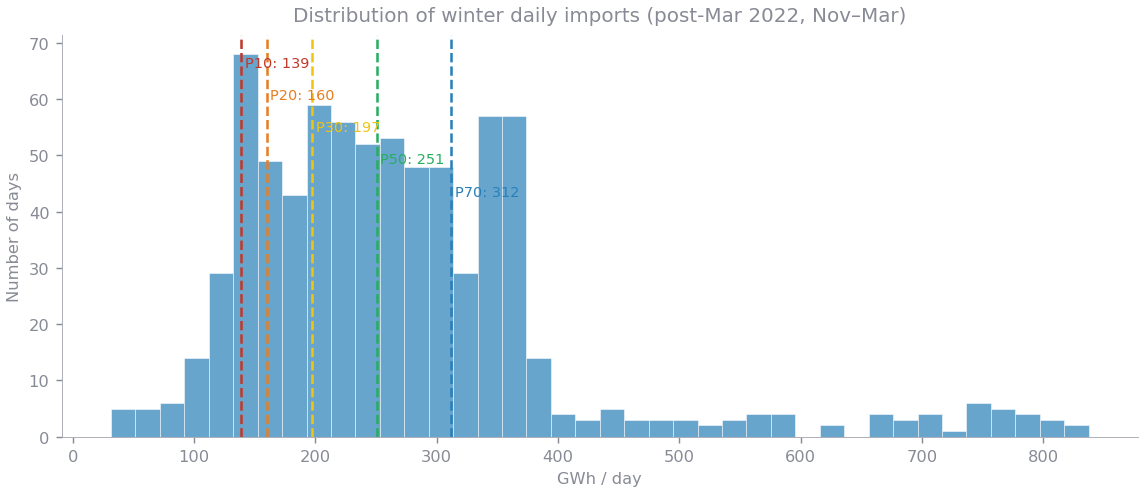

In [9]:
fig = bplot.winter_daily_histogram(
    daily,
    percentiles=[s.import_percentile for s in bcap.DEFAULT_SCENARIOS],
)
fig.savefig(FIGS_DIR / "winter_import_histogram.png", bbox_inches="tight")
fig;

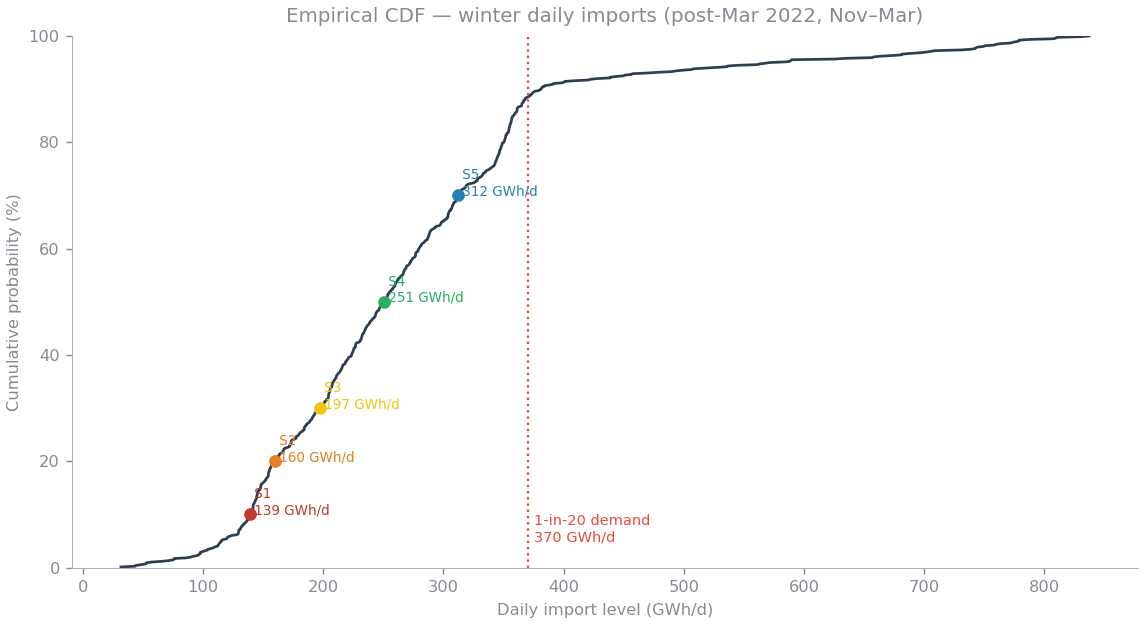

In [10]:
fig = bplot.winter_cdf(
    daily,
    scenarios=bcap.DEFAULT_SCENARIOS,
    peak_demand_GWh_d=PEAK_DEMAND_GWH_D,
)
fig.savefig(FIGS_DIR / "winter_import_cdf.png", bbox_inches="tight")
fig;

---
## 6. Storage sizing scenarios

We define five import-reliability scenarios that span from high-stress
(very low but historically observed imports) to favourable (above-median
imports).  For each scenario the storage requirement is:

```
storage_30d_GWh = max(0, peak_demand − 30d_sustained_import) × 30
```

where `30d_sustained_import` is the k-th percentile of the distribution of
30-day rolling average winter imports.

**Reading the table**  
- `reliable_import_daily_GWh_d` — on (100 − k)% of winter days, observed
  imports exceeded this level (single-day figure, for reference).
- `reliable_import_30d_avg_GWh_d` — the k-th percentile of 30-day average
  imports; this is what drives the storage calculation.
- `daily_gap_GWh_d` — the shortfall that storage must cover each day.
- `storage_30d_TWh` — minimum UGS working gas needed at start of cold period.

**Reference**: Czech UGS total working-gas capacity is approximately
**3.4 TWh** (NET4GAS-accessible).  Scenarios requiring more than this rely
on cross-border storage access (Austrian or Slovak UGS).

In [11]:
results = bcap.storage_scenarios(daily, peak_demand_GWh_d=PEAK_DEMAND_GWH_D)

display_cols = [
    "label",
    "reliable_import_daily_GWh_d",
    "reliable_import_30d_avg_GWh_d",
    "daily_gap_GWh_d",
    "storage_30d_GWh",
    "storage_30d_TWh",
]
results[display_cols]

,label,reliable_import_daily_GWh_d,reliable_import_30d_avg_GWh_d,daily_gap_GWh_d,storage_30d_GWh,storage_30d_TWh
0,S1 — High stress,139.1,156.4,213.6,6408.0,6.41
1,S2 — Stressed,159.9,188.8,181.2,5435.0,5.43
2,S3 — Base stressed,197.2,202.4,167.6,5027.0,5.03
3,S4 — Median,250.6,240.1,129.9,3897.0,3.90
4,S5 — Favourable,312.0,281.7,88.3,2649.0,2.65


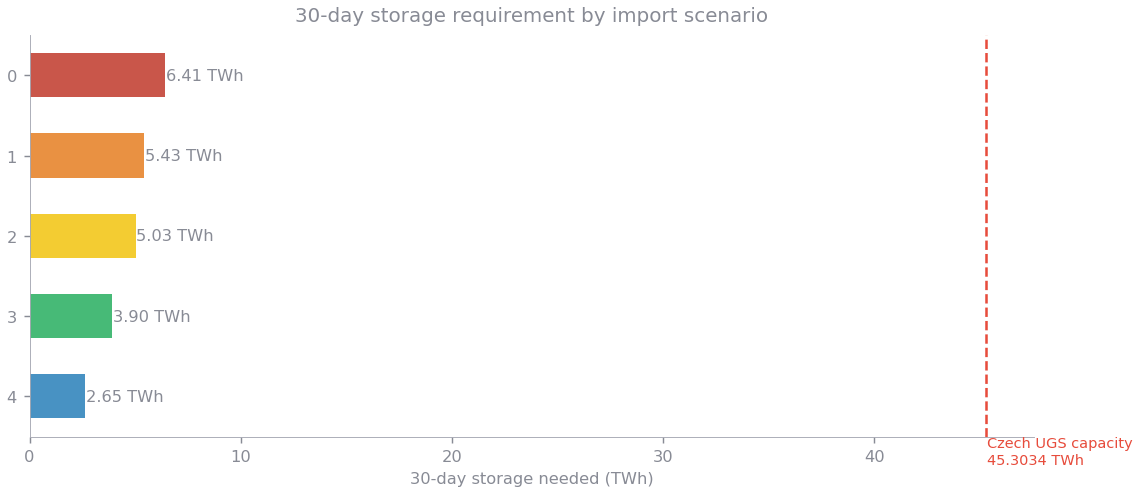

In [12]:
fig = bplot.scenario_bar(results, czechugs_capacity_TWh=CZECH_UGS_CAPACITY_TWH)
fig.savefig(FIGS_DIR / "storage_scenarios.png", bbox_inches="tight")
fig;

---
## 7. Scenario descriptions and discussion notes

The cell below prints the full narrative description of each scenario,
ready to copy into a presentation or briefing document.

In [13]:
for _, row in results.iterrows():
    print(f"{'─'*70}")
    print(f"{row['label']}  (P{row['import_percentile']} imports)")
    print(f"  {row['description']}")
    print(f"  Reliable 30d import : {row['reliable_import_30d_avg_GWh_d']:.0f} GWh/d")
    print(f"  Daily gap           : {row['daily_gap_GWh_d']:.0f} GWh/d")
    print(f"  Storage required    : {row['storage_30d_TWh']:.2f} TWh ({row['storage_30d_GWh']:.0f} GWh)")
print(f"{'─'*70}")
print(f"\nPeak demand assumption  : {PEAK_DEMAND_GWH_D} GWh/d (1-in-20)")
print(f"Czech UGS capacity ref  : {CZECH_UGS_CAPACITY_TWH} TWh")

──────────────────────────────────────────────────────────────────────
S1 — High stress  (P10 imports)
  Severe import shortfall (1-in-10 winter days worse than this). Represents a prolonged cold spell coinciding with low German hub supply or a single-corridor disruption.
  Reliable 30d import : 156 GWh/d
  Daily gap           : 214 GWh/d
  Storage required    : 6.41 TWh (6408 GWh)
──────────────────────────────────────────────────────────────────────
S2 — Stressed  (P20 imports)
  Significant import shortfall (1-in-5 winter days worse). Credible planning anchor: pairs a 1-in-20 demand event with a 1-in-5 import shortfall for a joint severity of roughly 1-in-100.
  Reliable 30d import : 189 GWh/d
  Daily gap           : 181 GWh/d
  Storage required    : 5.43 TWh (5435 GWh)
──────────────────────────────────────────────────────────────────────
S3 — Base stressed  (P30 imports)
  Moderate import shortfall (1-in-3 winter days worse). Represents a cold week with tighter-than-normal German 

---
## 8. Key caveats

1. **Single-corridor concentration.**  Post-2022 Czech imports are almost
   exclusively routed through the DE THE BZ interconnection (Germany).
   The scenarios implicitly assume no *additional* supply disruption beyond
   what is already reflected in historical low-flow days.  A full single-
   corridor failure would be a separate stress test with a hard import floor.

2. **Only four post-2022 winters.**  The empirical percentiles are calibrated
   on a relatively short sample.  If import volumes recover as European
   demand rebounds, the P10–P30 estimates will prove conservative (i.e.
   actual imports on stressed days will be higher), which *reduces* the
   storage requirement.  Monitor for season-on-season trends (Section 4).

3. **30-day storage horizon.**  The exercise assumes the cold spell lasts
   exactly 30 days.  Extending the horizon proportionally increases the
   storage requirement; the daily gap column makes this straightforward to
   recompute for alternative horizons.

4. **Peak demand is exogenous.**  The 370 GWh/d figure is taken as given.
   Sensitivity to this assumption is large: a ±50 GWh/d change in peak
   demand shifts the storage requirement by ±1.5 TWh across all scenarios.